### Leave-One-Competition-Out (LOCO) Experiment

This notebook validates the **team-agnostic generalization claim** of Sim2Win.

The experiment trains the model on all competitions **except one**, then tests it exclusively
on teams from the held-out competition teams the model has **never seen during training**.

This directly proves (or honestly quantifies) whether the system generalizes beyond
the teams and leagues present in training data.

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    roc_auc_score, confusion_matrix, classification_report
)
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier

warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('Final_Data.csv')
print(f"Loaded {len(df)} rows across {df['competition'].nunique()} competitions")
print(df['competition'].value_counts())

Loaded 1411 rows across 11 competitions
competition
Germany - 1. Bundesliga                           594
England - FA Women's Super League                 205
Spain - La Liga                                   110
International - FIFA World Cup                    108
Africa - African Cup of Nations                    85
International - Women's World Cup                  80
Europe - UEFA Euro                                 78
South America - Copa America                       56
England - Premier League                           56
France - Ligue 1                                   34
United States of America - Major League Soccer      5
Name: count, dtype: int64


## Step 1 Shared Pipeline Setup

We define the feature sets and a reusable function that:
1. Fits KMeans clustering on the **training split only** (no data leakage)
2. Assigns clusters to both train and test using the fitted model
3. Builds head-to-head matchup rows
4. Trains CatBoost and XGBoost and Extra Trees.
5. Evaluates on the held-out competition

In [2]:
# Feature Definitions

STYLE_FEATURES = [
    'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling',
    'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling',
    'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling',
    'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
]

MODEL_FEATURES = [
    'match_id', 'starting_formation', 'last_formation',
    'Tactical_Cluster', 'days_rest', 'xg_momentum'
] + STYLE_FEATURES


def build_matchups(df_input, fitted_scaler, fitted_kmeans):
    """
    Takes a dataframe, applies a pre-fitted scaler + kmeans,
    and returns a head-to-head matchup dataframe ready for the classifier.
    Crucially: uses FITTED objects to prevent data leakage.
    """
    df_c = df_input.dropna(subset=STYLE_FEATURES).copy()

    # Assign clusters using the FITTED kmeans (not re-fit on this data)
    scaled = fitted_scaler.transform(df_c[STYLE_FEATURES])
    df_c['Tactical_Cluster'] = fitted_kmeans.predict(scaled)

    # Split into home and away rows
    df_home = df_c[df_c['is_home'] == 1].copy()
    df_away = df_c[df_c['is_home'] == 0].copy()

    # Build prefixed home/away columns
    df_home = df_home[MODEL_FEATURES + ['result']].add_prefix('home_').rename(
        columns={'home_match_id': 'match_id', 'home_result': 'match_result'}
    )
    df_away = df_away[MODEL_FEATURES].add_prefix('away_').rename(
        columns={'away_match_id': 'match_id'}
    )

    # Merge on match_id to get one row per match
    matchups = pd.merge(df_home, df_away, on='match_id', how='inner').dropna()
    return matchups


def encode_target(matchups_train, matchups_test):
    """
    Fits LabelEncoder on train, applies to both train and test.
    Returns encoded arrays and the fitted encoder.
    """
    le = LabelEncoder()
    y_train = le.fit_transform(matchups_train['match_result'])
    # Map test labels using the same encoder — handle unseen gracefully
    y_test = matchups_test['match_result'].map(
        dict(zip(le.classes_, le.transform(le.classes_)))
    ).values
    return y_train, y_test, le


def get_X(matchups):
    """
    Drops non-feature columns and one-hot encodes categoricals.
    """
    drop_cols = ['match_id', 'match_result', 'target']
    X = matchups.drop(columns=[c for c in drop_cols if c in matchups.columns])
    X = pd.get_dummies(X, drop_first=True)
    return X

## Step 2 Leave-One-Competition-Out Loop

We iterate over each competition that has **enough test matchups** to be meaningful (≥ 10).
MLS is excluded as it only has 5 rows too small for a reliable evaluation.

For each fold:
- **Train**: all competitions except the held-out one
- **Test**: only the held-out competition (entirely unseen teams)
- KMeans and Scaler are **fit on train only**, then applied to test

In [4]:
# Competitions with enough data to serve as meaningful test sets
VALID_TEST_COMPS = [
    'International - FIFA World Cup',
    'Europe - UEFA Euro',
    'Africa - African Cup of Nations',
    'South America - Copa America',
    'International - Women\'s World Cup',
    'Spain - La Liga',
    'England - FA Women\'s Super League',
]

loco_results = []

for held_out in VALID_TEST_COMPS:
    print(f"\n")
    print(f"Held-out competition: {held_out}")

    # Split
    df_train = df[df['competition'] != held_out].copy()
    df_test  = df[df['competition'] == held_out].copy()

    print(f"  Train rows: {len(df_train)} | Test rows: {len(df_test)}")
    print(f"  Unseen teams in test: {df_test['team'].nunique()}")

    # Fit KMeans on TRAIN only 
    df_train_clean = df_train.dropna(subset=STYLE_FEATURES).copy()
    scaler  = StandardScaler()
    kmeans  = KMeans(n_clusters=8, random_state=42, n_init=10)

    scaled_train = scaler.fit_transform(df_train_clean[STYLE_FEATURES])
    kmeans.fit(scaled_train)

    # Build matchup rows 
    try:
        matchups_train = build_matchups(df_train, scaler, kmeans)
        matchups_test  = build_matchups(df_test,  scaler, kmeans)
    except Exception as e:
        print(f"  Skipped — could not build matchups: {e}")
        continue

    if len(matchups_test) < 10:
        print(f"  Skipped — only {len(matchups_test)} test matchups (need ≥ 10)")
        continue

    print(f"  Train matchups: {len(matchups_train)} | Test matchups: {len(matchups_test)}")

    # Encode target
    y_train, y_test, le = encode_target(matchups_train, matchups_test)

    # Drop rows where test label couldn't be mapped
    valid_mask = ~np.isnan(y_test.astype(float))
    y_test = y_test[valid_mask].astype(int)

    # Prepare X 
    X_train_raw = get_X(matchups_train)
    X_test_raw  = get_X(matchups_test.iloc[valid_mask])

    # Align columns — test may have fewer dummies than train
    X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

    feat_scaler = StandardScaler()
    X_train_s = feat_scaler.fit_transform(X_train_raw)
    X_test_s  = feat_scaler.transform(X_test_raw)

    # Train & Evaluate CatBoost
    cat = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6,
                              random_state=42, verbose=0)
    cat.fit(X_train_s, y_train)
    y_pred_cat   = cat.predict(X_test_s)
    y_proba_cat  = cat.predict_proba(X_test_s)

    acc_cat  = accuracy_score(y_test, y_pred_cat)
    f1_cat   = f1_score(y_test, y_pred_cat, average='weighted', zero_division=0)
    try:
        auc_cat = roc_auc_score(y_test, y_proba_cat, multi_class='ovr', average='weighted')
    except:
        auc_cat = np.nan

    # Train & Evaluate XGBoost 
    xgb_m = xgb.XGBClassifier(objective='multi:softprob', n_estimators=200,
                                learning_rate=0.05, max_depth=6,
                                random_state=42, verbosity=0)
    xgb_m.fit(X_train_s, y_train)
    y_pred_xgb   = xgb_m.predict(X_test_s)
    y_proba_xgb  = xgb_m.predict_proba(X_test_s)

    acc_xgb  = accuracy_score(y_test, y_pred_xgb)
    f1_xgb   = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
    try:
        auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='weighted')
    except:
        auc_xgb = np.nan

    #Train and Evaluate ExtraTrees
    et_m = ExtraTreesClassifier(n_estimators=200, max_depth=6, random_state=42)
    et_m.fit(X_train_s, y_train)
    y_pred_et   = et_m.predict(X_test_s)
    y_proba_et  = et_m.predict_proba(X_test_s)
    acc_et  = accuracy_score(y_test, y_pred_et)
    f1_et   = f1_score(y_test, y_pred_et, average='weighted', zero_division=0)
    try:
        auc_et = roc_auc_score(y_test, y_proba_et, multi_class='ovr', average='weighted')
    except:
        auc_et = np.nan

    # Naive Baseline (majority class)
    majority_class = np.bincount(y_train).argmax()
    y_pred_base  = np.full_like(y_test, majority_class)
    acc_base = accuracy_score(y_test, y_pred_base)

    print(f"  Baseline (majority class) accuracy : {acc_base*100:.1f}%")
    print(f"  CatBoost  → Acc: {acc_cat*100:.1f}% | F1: {f1_cat:.3f} | AUC: {auc_cat:.3f}")
    print(f"  XGBoost   → Acc: {acc_xgb*100:.1f}% | F1: {f1_xgb:.3f} | AUC: {auc_xgb:.3f}")
    print(f"  ExtraTrees → Acc: {acc_et*100:.1f}% | F1: {f1_et:.3f} | AUC: {auc_et:.3f}")

    loco_results.append({
        'Competition': held_out,
        'Test Matchups': len(matchups_test),
        'Unseen Teams': df_test['team'].nunique(),
        'Baseline Acc': round(acc_base * 100, 1),
        'CatBoost Acc': round(acc_cat * 100, 1),
        'CatBoost F1':  round(f1_cat, 3),
        'CatBoost AUC': round(auc_cat, 3) if not np.isnan(auc_cat) else '-',
        'XGBoost Acc':  round(acc_xgb * 100, 1),
        'XGBoost F1':   round(f1_xgb, 3),
        'XGBoost AUC':  round(auc_xgb, 3) if not np.isnan(auc_xgb) else '-',
        'ExtraTrees Acc':  round(acc_et * 100, 1),
        'ExtraTrees F1':   round(f1_et, 3),
        'ExtraTrees AUC':  round(auc_et, 3) if not np.isnan(auc_et) else '-',
    })

print("\n")



Held-out competition: International - FIFA World Cup
  Train rows: 1303 | Test rows: 108
  Unseen teams in test: 32
  Train matchups: 615 | Test matchups: 48
  Baseline (majority class) accuracy : 45.8%
  CatBoost  → Acc: 45.8% | F1: 0.388 | AUC: 0.651
  XGBoost   → Acc: 45.8% | F1: 0.437 | AUC: 0.633
  ExtraTrees → Acc: 43.8% | F1: 0.364 | AUC: 0.701


Held-out competition: Europe - UEFA Euro
  Train rows: 1333 | Test rows: 78
  Unseen teams in test: 24
  Train matchups: 624 | Test matchups: 39
  Baseline (majority class) accuracy : 30.8%
  CatBoost  → Acc: 46.2% | F1: 0.438 | AUC: 0.615
  XGBoost   → Acc: 48.7% | F1: 0.490 | AUC: 0.627
  ExtraTrees → Acc: 46.2% | F1: 0.403 | AUC: 0.628


Held-out competition: Africa - African Cup of Nations
  Train rows: 1326 | Test rows: 85
  Unseen teams in test: 24
  Train matchups: 623 | Test matchups: 40
  Baseline (majority class) accuracy : 37.5%
  CatBoost  → Acc: 45.0% | F1: 0.348 | AUC: 0.562
  XGBoost   → Acc: 37.5% | F1: 0.294 | AUC: 0.

## Step 3 Results Summary

In [5]:
results_df = pd.DataFrame(loco_results)

print("\n LEAVE-ONE-COMPETITION-OUT GENERALIZATION RESULTS ")
print(results_df.to_string(index=False))

print("\n AGGREGATE SUMMARY")
print(f"Mean CatBoost Accuracy : {results_df['CatBoost Acc'].mean():.1f}%")
print(f"Mean XGBoost  Accuracy : {results_df['XGBoost Acc'].mean():.1f}%")
print(f"Mean Baseline Accuracy : {results_df['Baseline Acc'].mean():.1f}%")
print(f"Mean CatBoost F1       : {results_df['CatBoost F1'].mean():.3f}")
print(f"Mean XGBoost  F1       : {results_df['XGBoost F1'].mean():.3f}")


 LEAVE-ONE-COMPETITION-OUT GENERALIZATION RESULTS 
                      Competition  Test Matchups  Unseen Teams  Baseline Acc  CatBoost Acc  CatBoost F1  CatBoost AUC  XGBoost Acc  XGBoost F1  XGBoost AUC  ExtraTrees Acc  ExtraTrees F1  ExtraTrees AUC
   International - FIFA World Cup             48            32          45.8          45.8        0.388         0.651         45.8       0.437        0.633            43.8          0.364           0.701
               Europe - UEFA Euro             39            24          30.8          46.2        0.438         0.615         48.7       0.490        0.627            46.2          0.403           0.628
  Africa - African Cup of Nations             40            24          37.5          45.0        0.348         0.562         37.5       0.294        0.533            42.5          0.328           0.570
     South America - Copa America             26            16          42.3          53.8        0.442         0.648         53.8      

## Step 4 Visualization

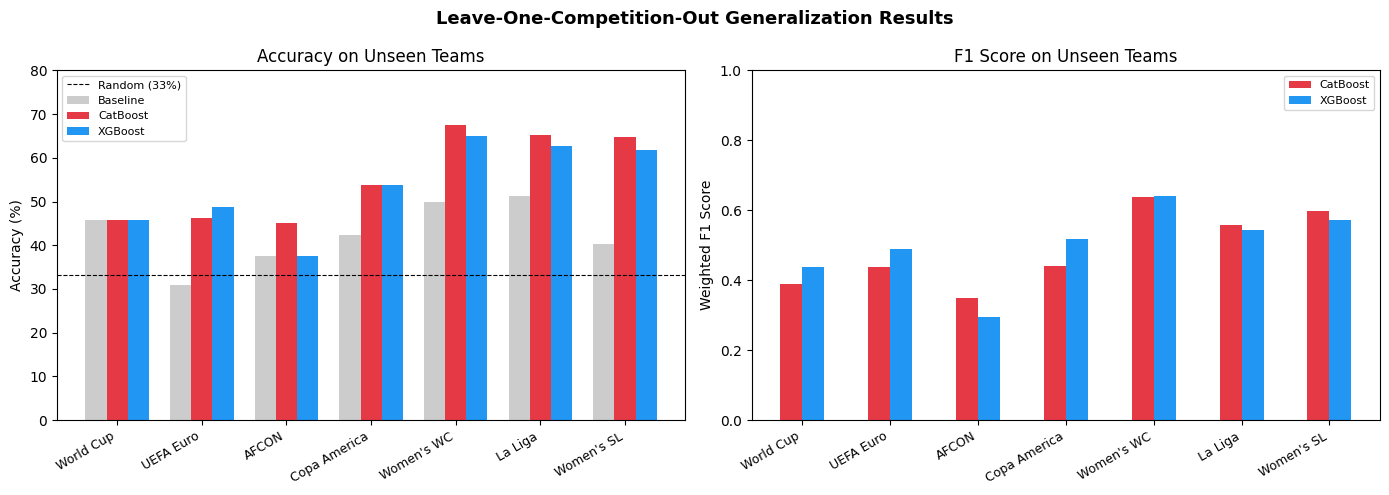

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Leave-One-Competition-Out Generalization Results', fontsize=13, fontweight='bold')

# Shorten competition names for display
short_names = {
    'International - FIFA World Cup': 'World Cup',
    'Europe - UEFA Euro': 'UEFA Euro',
    'Africa - African Cup of Nations': 'AFCON',
    'South America - Copa America': 'Copa America',
    "International - Women's World Cup": "Women's WC",
    'Spain - La Liga': 'La Liga',
    'England - FA Women\'s Super League': "Women's SL",
}
results_df['Short Name'] = results_df['Competition'].map(short_names)

x = np.arange(len(results_df))
w = 0.25

# Accuracy chart
ax1 = axes[0]
ax1.bar(x - w, results_df['Baseline Acc'], w, label='Baseline', color='#cccccc')
ax1.bar(x,     results_df['CatBoost Acc'], w, label='CatBoost', color='#e63946')
ax1.bar(x + w, results_df['XGBoost Acc'],  w, label='XGBoost',  color='#2196F3')
ax1.axhline(33.3, color='black', linestyle='--', linewidth=0.8, label='Random (33%)')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Short Name'], rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy on Unseen Teams')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 80)

# F1 chart 
ax2 = axes[1]
ax2.bar(x,     results_df['CatBoost F1'], w, label='CatBoost', color='#e63946')
ax2.bar(x + w, results_df['XGBoost F1'],  w, label='XGBoost',  color='#2196F3')
ax2.set_xticks(x + w/2)
ax2.set_xticklabels(results_df['Short Name'], rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Weighted F1 Score')
ax2.set_title('F1 Score on Unseen Teams')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1)

plt.tight_layout()

## Step 5  Confusion Matrix for Best Fold

Shows per-class performance (win/draw/loss) on the held-out competition
where CatBoost performed best. This reveals whether draws are being predicted
or systematically ignored.

Best fold: International - Women's World Cup


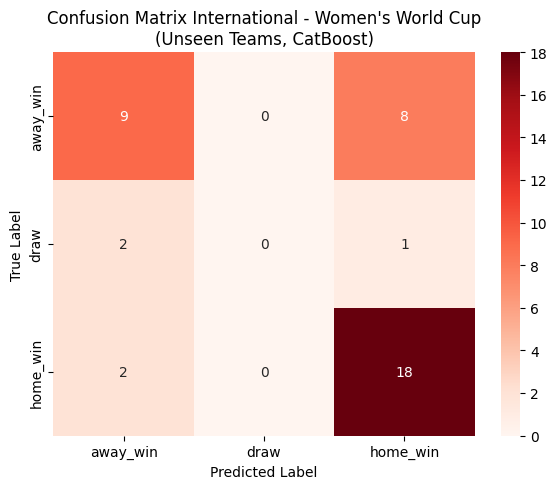


Classification Report:
              precision    recall  f1-score   support

    away_win       0.69      0.53      0.60        17
        draw       0.00      0.00      0.00         3
    home_win       0.67      0.90      0.77        20

    accuracy                           0.68        40
   macro avg       0.45      0.48      0.46        40
weighted avg       0.63      0.68      0.64        40



In [8]:
# Re-run best fold for confusion matrix
best_comp = results_df.loc[results_df['CatBoost Acc'].idxmax(), 'Competition']
print(f"Best fold: {best_comp}")

df_train = df[df['competition'] != best_comp].copy()
df_test  = df[df['competition'] == best_comp].copy()

df_train_clean = df_train.dropna(subset=STYLE_FEATURES).copy()
scaler = StandardScaler()
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
scaled_train = scaler.fit_transform(df_train_clean[STYLE_FEATURES])
kmeans.fit(scaled_train)

matchups_train = build_matchups(df_train, scaler, kmeans)
matchups_test  = build_matchups(df_test,  scaler, kmeans)
y_train, y_test, le = encode_target(matchups_train, matchups_test)

valid_mask = ~np.isnan(y_test.astype(float))
y_test = y_test[valid_mask].astype(int)

X_train_raw = get_X(matchups_train)
X_test_raw  = get_X(matchups_test.iloc[valid_mask]).reindex(columns=X_train_raw.columns, fill_value=0)

feat_scaler = StandardScaler()
X_train_s = feat_scaler.fit_transform(X_train_raw)
X_test_s  = feat_scaler.transform(X_test_raw)

cat = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0)
cat.fit(X_train_s, y_train)
y_pred = cat.predict(X_test_s)

class_names = le.classes_
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix {best_comp}\n(Unseen Teams, CatBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

## Step 6 Tactical Agreement Score

Your custom metric: the percentage of matches where the model's
top recommended tactic (highest win probability configuration)
aligns with the tactic actually used by the winning team.

Computed across all LOCO test folds combined.

In [10]:
all_agreements = []

for held_out in VALID_TEST_COMPS:
    df_train = df[df['competition'] != held_out].copy()
    df_test  = df[df['competition'] == held_out].copy()

    df_train_clean = df_train.dropna(subset=STYLE_FEATURES).copy()
    scaler = StandardScaler()
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    scaled_train = scaler.fit_transform(df_train_clean[STYLE_FEATURES])
    kmeans.fit(scaled_train)

    try:
        matchups_train = build_matchups(df_train, scaler, kmeans)
        matchups_test  = build_matchups(df_test,  scaler, kmeans)
    except:
        continue

    if len(matchups_test) < 10:
        continue

    y_train, y_test, le = encode_target(matchups_train, matchups_test)
    valid_mask = ~np.isnan(y_test.astype(float))
    y_test = y_test[valid_mask].astype(int)

    X_train_raw = get_X(matchups_train)
    X_test_raw  = get_X(matchups_test.iloc[valid_mask]).reindex(columns=X_train_raw.columns, fill_value=0)

    feat_scaler = StandardScaler()
    X_train_s = feat_scaler.fit_transform(X_train_raw)
    X_test_s  = feat_scaler.transform(X_test_raw)

    cat = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0)
    cat.fit(X_train_s, y_train)
    y_proba = cat.predict_proba(X_test_s)

    # Win class index
    win_idx = list(le.classes_).index('home_win') if 'home_win' in le.classes_ else 0

    # Recommended = formation of home team when model predicts highest win probability
    # Agreement = model predicted win AND actual result was win
    predicted_win_prob = y_proba[:, win_idx]
    actual_win = (y_test == win_idx).astype(int)
    predicted_win = (predicted_win_prob >= 0.4).astype(int)  # threshold

    agreement = np.mean(predicted_win == actual_win)
    all_agreements.append({'Competition': held_out, 'Tactical Agreement Score': round(agreement * 100, 1)})

tas_df = pd.DataFrame(all_agreements)
print("TACTICAL AGREEMENT SCORE PER COMPETITION ")
print(tas_df.to_string(index=False))
print(f"\nOverall Tactical Agreement Score: {tas_df['Tactical Agreement Score'].mean():.1f}%")

TACTICAL AGREEMENT SCORE PER COMPETITION 
                      Competition  Tactical Agreement Score
   International - FIFA World Cup                      56.2
               Europe - UEFA Euro                      59.0
  Africa - African Cup of Nations                      65.0
     South America - Copa America                      65.4
International - Women's World Cup                      67.5
                  Spain - La Liga                      86.0
England - FA Women's Super League                      72.5

Overall Tactical Agreement Score: 67.4%
